## Part (a): Support Vector Machine

### Data loading

In [ ]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

train_data = np.loadtxt('xy_train.csv', delimiter=',')
X_train = train_data[:, :2]
y_train = train_data[:, 2]

test_data = np.loadtxt('xy_test.csv', delimiter=',')
X_test = test_data[:, :2]
y_test = test_data[:, 2]

# Ensure labels are -1 / +1
if np.any(y_train == 0):
    y_train = 2 * y_train - 1
    y_test  = 2 * y_test  - 1

### i. Solve SVM with C=1

Define the SVM problem:
$$ \min_{\beta,\beta_0,\xi} \ \frac12 \|\beta\|_2^2 + C\sum_{i=1}^n \xi_i $$
$$ \text{s.t. } \xi_i \ge 0, \ \ y_i(x_i^\top\beta + \beta_0) \ge 1 - \xi_i \ \forall i $$

In [23]:
n_train = X_train.shape[0]
p = X_train.shape[1]

C = 1.0

beta = cp.Variable(p)
beta0 = cp.Variable()
xi = cp.Variable(n_train, nonneg=True)

objective = 0.5 * cp.sum_squares(beta) + C * cp.sum(xi)
constraints = [cp.multiply(y_train, X_train @ beta + beta0) >= 1 - xi]

prob = cp.Problem(cp.Minimize(objective), constraints)
prob.solve()

print("Optimal value:", prob.value)
print("beta:", beta.value)
print("beta0:", beta0.value)

Optimal value: 36.748932649263416
beta: [1.41967191 1.24607477]
beta0: -2.823727594195054


### ii. Plot decision boundary

The decision boundary is $\beta_0 + \beta^\top x = 0$.

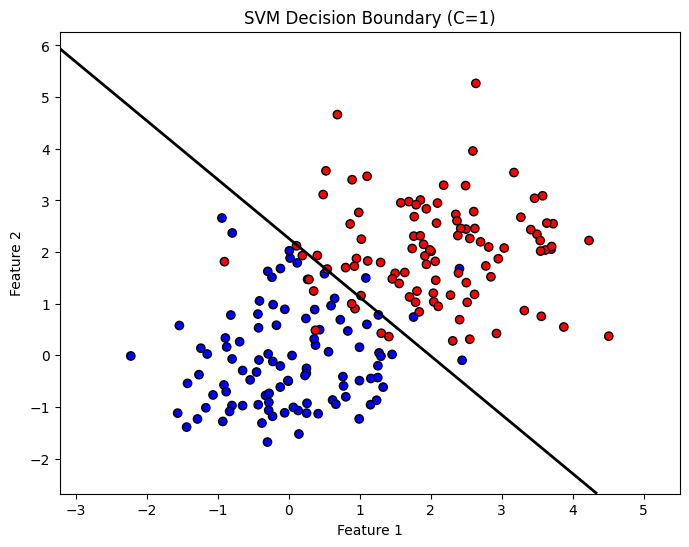

In [24]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

z = beta0.value + beta.value[0] * xx + beta.value[1] * yy

plt.figure(figsize=(8, 6))
plt.contour(xx, yy, z, levels=[0], colors='k', linewidths=2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary (C=1)')
plt.show()

### iii. Dual-like problem

Define $\tilde{X}$ with rows $\tilde{x}_i = y_i x_i$. Solve:
$$ \max_{w} \ -\frac12 w^\top \tilde{X}\tilde{X}^\top w + \mathbf{1}^\top w $$
$$ \text{s.t. } 0 \le w \le C, \quad w^\top y = 0 $$

In [25]:
X_tilde = y_train[:, None] * X_train

w = cp.Variable(n_train)
obj_dual = -0.5 * cp.sum_squares(X_tilde.T @ w) + cp.sum(w)
constraints_dual = [w >= 0, w <= C, w.T @ y_train == 0]

prob_dual = cp.Problem(cp.Maximize(obj_dual), constraints_dual)
prob_dual.solve()

print("Dual optimal value:", prob_dual.value)
print("Primal optimal value:", prob.value)
print("beta from dual (X_tilde^T w):", (X_tilde.T @ w).value)
print("beta from primal:", beta.value)

Dual optimal value: 36.54676673663892
Primal optimal value: 36.748932649263416
beta from dual (X_tilde^T w): [1.41922771 1.24558068]
beta from primal: [1.41967191 1.24607477]


C:\Users\zafar\AppData\Local\Temp\ipykernel_12600\639277919.py:8: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob_dual.solve()


### iv. Varying C and test error

Loop over $C = 2^a$ for $a \in \{-5,-4,\dots,5\}$, solve SVM, compute misclassification error on test set, then plot.

C:\Users\zafar\AppData\Local\Temp\ipykernel_12600\111291109.py:13: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob_c.solve()


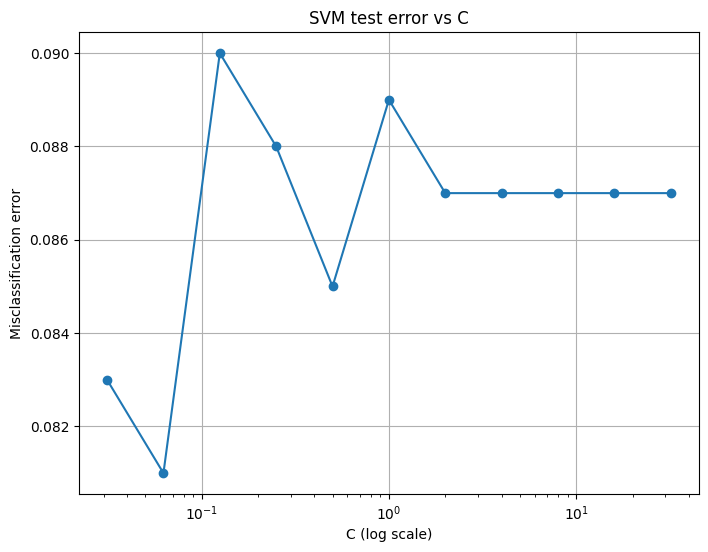

In [26]:
C_values = [2**a for a in range(-5, 6)]
errors = []

for C in C_values:
    beta_c = cp.Variable(p)
    beta0_c = cp.Variable()
    xi_c = cp.Variable(n_train, nonneg=True)

    obj_c = 0.5 * cp.sum_squares(beta_c) + C * cp.sum(xi_c)
    constraints_c = [cp.multiply(y_train, X_train @ beta_c + beta0_c) >= 1 - xi_c]

    prob_c = cp.Problem(cp.Minimize(obj_c), constraints_c)
    prob_c.solve()

    scores = beta0_c.value + X_test @ beta_c.value
    y_pred = np.sign(scores)
    error = np.mean(y_pred != y_test)
    errors.append(error)

plt.figure(figsize=(8, 6))
plt.semilogx(C_values, errors, marker='o')
plt.xlabel('C (log scale)')
plt.ylabel('Misclassification error')
plt.title('SVM test error vs C')
plt.grid(True)
plt.show()